<h2 style="color: deeppink;">Diabetes Classification Project</h2>
In this project we have a diabetes dataset, we're going to analyze the data, use Logistic Regression, KNN and Naive Bayes techniques to find the best performing model based on F1-score and ROC-AUC, given the class imbalance in the dataset. We'll predict whether a person has diebetes or not given the info such as gender, age, hypertension, etc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
data = pd.read_csv('diabetes_prediction_dataset.csv')
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
data.gender = (data.gender == 'Female').astype('int8')

In [5]:
data.describe()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.585520,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,0.492635,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.000000,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,0.000000,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,1.000000,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,1.000000,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,never,25.19,6.6,140,0
1,1,54.0,0,0,No Info,27.32,6.6,80,0
2,0,28.0,0,0,never,27.32,5.7,158,0
3,1,36.0,0,0,current,23.45,5.0,155,0
4,0,76.0,1,1,current,20.14,4.8,155,0


In [7]:
a = data.smoking_history.value_counts()
a 

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [8]:
for v in a.keys():
    data[v] = (data.smoking_history == v).astype('int8')
data.drop('smoking_history', axis=1, inplace = True)
data.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,No Info,never,former,current,not current,ever
0,1,80.0,0,1,25.19,6.6,140,0,0,1,0,0,0,0
1,1,54.0,0,0,27.32,6.6,80,0,1,0,0,0,0,0
2,0,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0
3,1,36.0,0,0,23.45,5.0,155,0,0,0,0,1,0,0
4,0,76.0,1,1,20.14,4.8,155,0,0,0,0,1,0,0


In [9]:
counts = data.diabetes.value_counts()
counts

diabetes
0    91500
1     8500
Name: count, dtype: int64

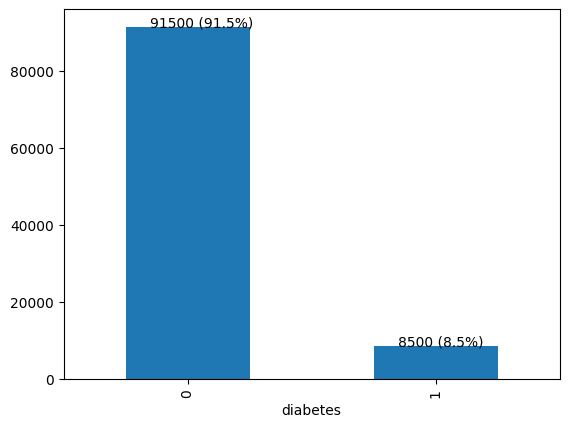

In [10]:
ax = counts.plot(kind = 'bar')
for p in ax.patches:
    ax.annotate(f"{p.get_height()} ({p.get_height()/len(data) * 100 :.1f}%)", (p.get_x() + 0.1, p.get_height() + 50))

<Axes: >

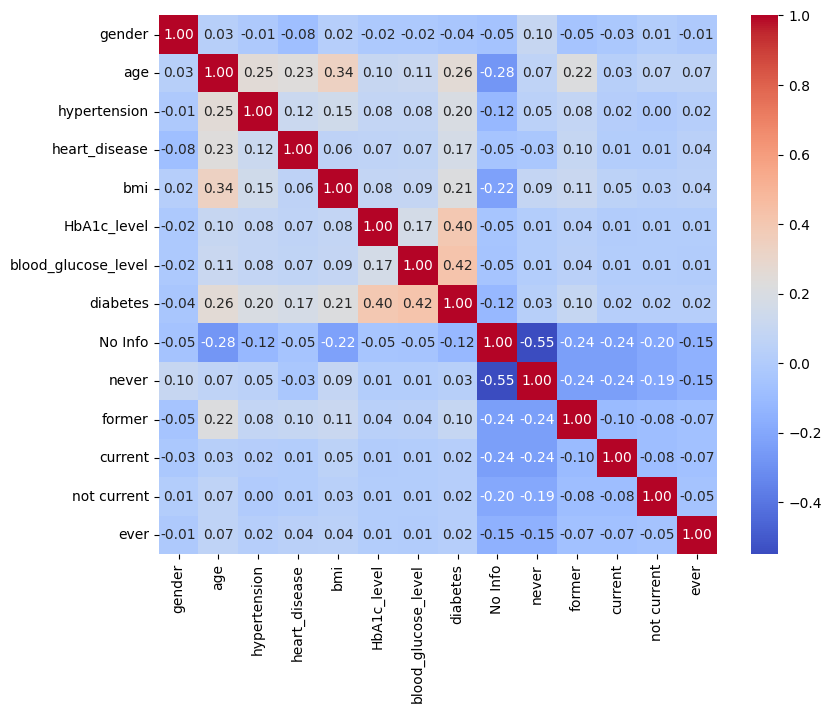

In [11]:
plt.figure(figsize = (9,7))
sns.heatmap(data.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')

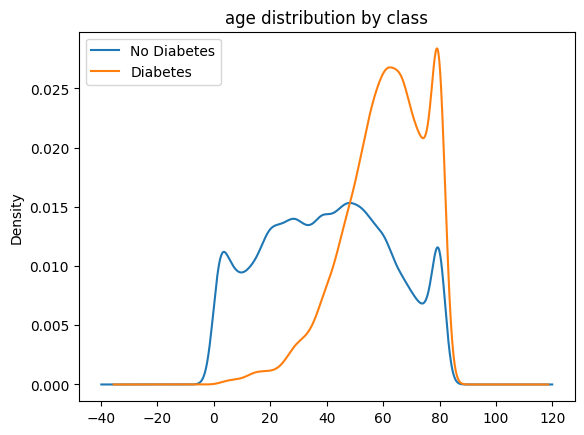

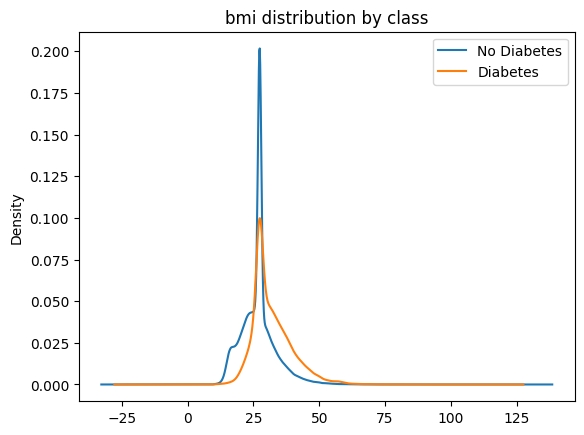

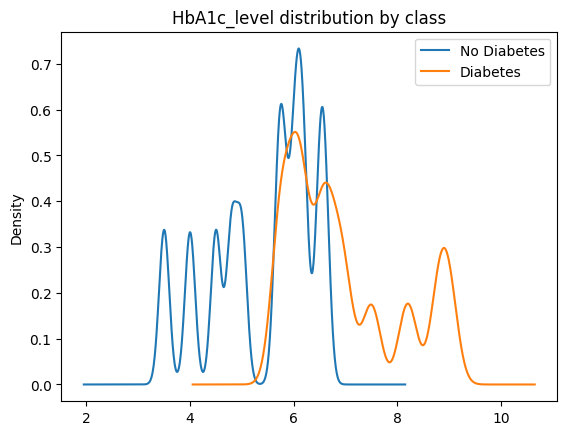

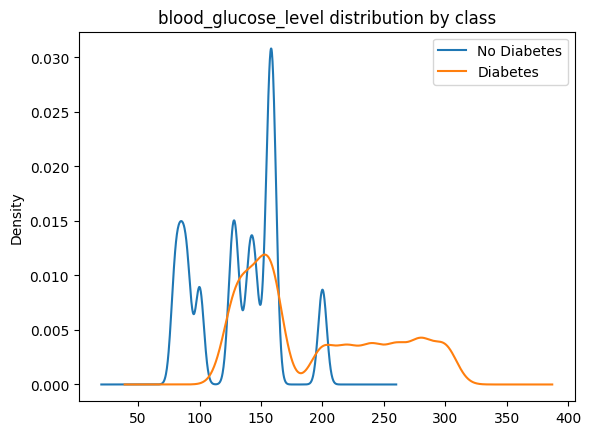

In [12]:
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
for col in numeric_features:
    plt.figure()
    data[data['diabetes'] == 0][col].plot(kind='kde', label='No Diabetes')
    data[data['diabetes'] == 1][col].plot(kind='kde', label='Diabetes')
    plt.title(f'{col} distribution by class')
    plt.legend()
    plt.show()

<Axes: xlabel='diabetes', ylabel='bmi'>

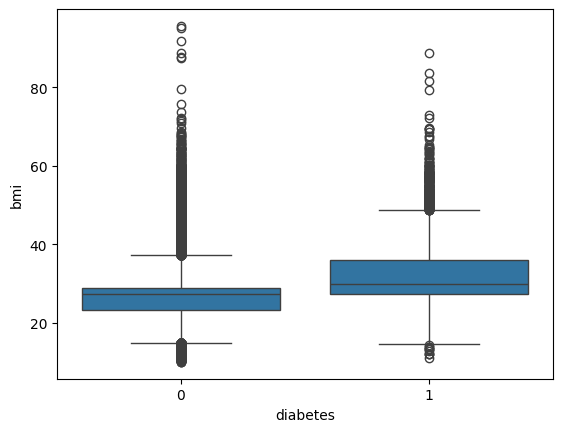

In [13]:
sns.boxplot(x='diabetes', y='bmi', data=data)


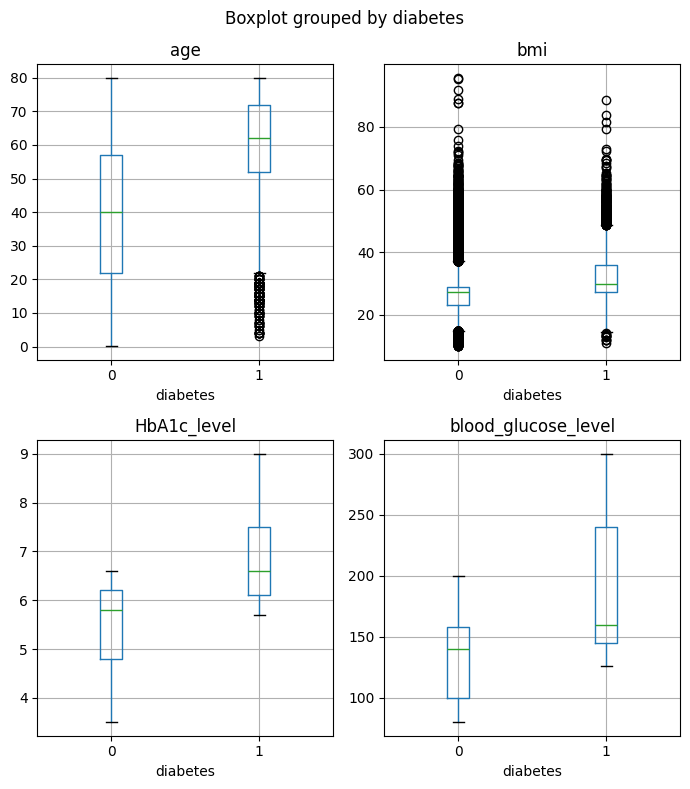

In [14]:
cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, ax = plt.subplots(math.ceil(len(cols)/2), 2, figsize = (7,8))
ax = ax.flatten()
for i,v in enumerate(cols):
    data.boxplot(column = v, by = 'diabetes', ax = ax[i])
plt.tight_layout()
for i in range(len(cols),len(ax)):
    plt.delaxes(ax[i])
plt.show()    

In [15]:
def remove_outliers(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    iqr = Q3-Q1
    data = data[(data[feature]>= Q1-1.5*iqr)&(data[feature]<= Q3+1.5*iqr)]
    return data

In [16]:
for c in cols:
    data = remove_outliers(data, c)

In [17]:
data.shape

(90387, 14)

## EDA: 
Let's analyze what we have so far. Having 100000 rows × 9 columns diabetes dataset:
1. I found out that the dataset is highly imbalanced (91.5% non-diabetes, 8.5% diabetes data).
2. Performed feature-engineering and transformed <u>gender</u> column into binary representation and performed one-hot encoding on <u>smoking_history</u> feature.
3. Displayed heatmap showing correlations between features. Strongest correlations with the target are 0.42 & 0.40 ('blood_glucose_level','HbA1c_level'), with no single feature being a dominant linear predictor. No severe multicollinearity between features except among one-hot encoded smoking_history columns, which is expected.
4. Plotted comparisons of diabetes and non-diabetes by <b>kde</b> (Kernel Density Estimation) plots.
5. Checked whether the numerical features had outliers via boxplots, removed them with the IQR technique

In [18]:
x = data.drop('diabetes', axis = 1).values
y = data.diabetes.values
print(x.shape)
print(y.shape)

(90387, 13)
(90387,)


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [20]:
l = LogisticRegression(class_weight = 'balanced', random_state = 0)
l.fit(x_train_sc, y_train)
y_pr = l.predict(x_test_sc)
y_prob = l.predict_proba(x_test_sc)[:,1]

In [21]:
print(classification_report(y_test, y_pr))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     17237
           1       0.21      0.89      0.34       841

    accuracy                           0.84     18078
   macro avg       0.60      0.86      0.63     18078
weighted avg       0.96      0.84      0.88     18078

ROC-AUC: 0.9417


In [22]:
cm = confusion_matrix(y_test, y_pr)
tn, fp, fn, tp = cm.ravel()
print(cm)
recall = tp/(tp+fn)
precision = tp/(tp+fp)
print(f"Precision: {precision:.4f}")
print(f"Recall(Sensivity): {recall:.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")
print(f"F1 score: {2*recall*precision/(recall+precision):.4f}")

[[14484  2753]
 [   96   745]]
Precision: 0.2130
Recall(Sensivity): 0.8859
Specificity: 0.8403
F1 score: 0.3434


In [23]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(x_train_sc, y_train)
y_pred_knn = knn.predict(x_test_sc)
y_prob_knn = knn.predict_proba(x_test_sc)[:,1]
tn,fp,fn,tp = confusion_matrix(y_test, y_pred_knn).ravel()
print(f'TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}')
print(f'Precision: {tp / (tp + fp):.4f}')
print(f'Recall (Sensitivity): {tp / (tp + fn):.4f}')
print(f'Specificity: {tn / (tn + fp):.4f}')
print(f'F1: {f1_score(y_test, y_pred_knn):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_knn):.4f}')

TP: 340, TN: 17072, FP: 165, FN: 501
Precision: 0.6733
Recall (Sensitivity): 0.4043
Specificity: 0.9904
F1: 0.5052
ROC-AUC: 0.8494


Specificity: 0.990 — nearly perfect at identifying non-diabetics. Almost no false alarms.
Precision: 0.673 — when it predicts diabetic, it's right 67% of the time. Much better than LR's 21%.
Recall: 0.404 — only catches 40% of actual diabetics. Misses 501 of 841. This is concerning in a medical context.
F1: 0.505 — better than LR's 0.343.
ROC-AUC: 0.849 — strong, meaning the model ranks diabetics above non-diabetics well overall.

In [24]:
nb = GaussianNB(priors=[0.5, 0.5])
nb.fit(x_train_sc,y_train)
y_pred_nb = nb.predict(x_test_sc)
y_prob_nb = nb.predict_proba(x_test_sc)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_nb).ravel()

print(f'TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}')
print(f'Precision: {tp / (tp + fp):.4f}')
print(f'Recall (Sensitivity): {tp / (tp + fn):.4f}')
print(f'Specificity: {tn / (tn + fp):.4f}')
print(f'F1: {f1_score(y_test, y_pred_nb):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_nb):.4f}')

TP: 630, TN: 14515, FP: 2722, FN: 211
Precision: 0.1879
Recall (Sensitivity): 0.7491
Specificity: 0.8421
F1: 0.3005
ROC-AUC: 0.8862


## Conclusion
We trained and evaluated three classification models on a highly imbalanced diabetes dataset (91.5% non-diabetic, 8.5% diabetic), using F1-score and ROC-AUC as primary metrics.

Each model made a distinct tradeoff between precision and recall:

- **Logistic Regression** achieved the highest recall (88.6%), catching the most diabetic cases at the cost of many false positives. The `class_weight='balanced'` parameter pushed it aggressively toward the minority class.
- **KNN** was the most conservative model — highest precision (67.3%) and near-perfect specificity (99%), but missed 60% of actual diabetics.
- **Naive Bayes** achieved the highest ROC-AUC (0.886) despite its naive independence assumption, but had the lowest F1 and precision of the three.

**By F1-score:** KNN is the best performing model (0.505).  
**By ROC-AUC:** Naive Bayes ranks diabetics above non-diabetics most effectively (0.886).  
**By medical utility:** Logistic Regression is the most practical — in a clinical screening context, missing a diabetic patient is far more dangerous than a false alarm that leads to further testing.